# Overview
The assessment involves object detection in a retail setting using image detection models. This can prove to be quite a useful approach to taking stock counts in a retail store at the end of quarters, which typically requires time-consuming manual counting.

The task requires building a model which delivers acceptable metrics in detecting all the required stocks while also making sure the items detected and classified are as accurate as possible. This would in turn make the model suitable in the practical world.

The task also requires displaying product dominance in a collective shelf.

# The Dataset

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import yaml

yaml_path = "/content/drive/MyDrive/dataset/data.yaml"

with open(yaml_path, "r") as f:
    data = yaml.safe_load(f)

!cat {yaml_path}

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 76
names: ['q1', 'q10', 'q100', 'q103', 'q106', 'q109', 'q112', 'q115', 'q118', 'q121', 'q13', 'q130', 'q133', 'q136', 'q142', 'q145', 'q148', 'q151', 'q157', 'q16', 'q163', 'q169', 'q175', 'q178', 'q184', 'q187', 'q19', 'q190', 'q193', 'q196', 'q199', 'q202', 'q211', 'q214', 'q22', 'q220', 'q229', 'q232', 'q247', 'q25', 'q250', 'q256', 'q262', 'q265', 'q268', 'q271', 'q274', 'q280', 'q286', 'q289', 'q291', 'q293', 'q299', 'q31', 'q34', 'q37', 'q4', 'q40', 'q46', 'q49', 'q52', 'q55', 'q58', 'q61', 'q64', 'q67', 'q7', 'q70', 'q73', 'q76', 'q79', 'q82', 'q88', 'q91', 'q94', 'q97']

roboflow:
  workspace: project-6jait
  project: final_try
  version: 4
  license: CC BY 4.0
  url: https://universe.roboflow.com/project-6jait/final_try/dataset/4

The dataset is being loaded from google drive, as the assignment is being done from Google Colab. This requires tweaking of the data.yaml file to ensure proper access.

In [3]:
new_data = {
    "path": "/content/drive/MyDrive/dataset",
    "train": "train/images",
    "val": "valid/images",
    "test": "test/images",
    "nc": data["nc"],
    "names": data["names"],
    "roboflow": data["roboflow"]
}



There is a total of 76 classes of stock, with a unique code for each class

In [4]:
with open(yaml_path, "w") as f:
    yaml.dump(new_data, f, sort_keys=False, default_flow_style=False)

##Exploratory Data Analysis

Let us look at the training data

In [5]:
import os

dataset_path = "/content/drive/MyDrive/dataset/train"
image_folder = os.path.join(dataset_path, "images")
label_folder = os.path.join(dataset_path, "labels")

In [6]:
files = sorted(os.listdir(image_folder))
print("Training images: ", files[:10])


files = sorted(os.listdir(label_folder))
print("Training labels: ", files[:10])

Training images:  ['db1021_jpg.rf.58ac3404fb4f7c4c9e76a628ea49b1ac.jpg', 'db1021_jpg.rf.dddc8ab6d1430803a7bd5d2f74304dfb.jpg', 'db1021_jpg.rf.f3408917337ae2bb9fa8b132c4441a3d.jpg', 'db1022_jpg.rf.12d47fccf92b91dd700cad6b7f3b426e.jpg', 'db1022_jpg.rf.b32fb2bca32f54888e666a65d1fdb2d5.jpg', 'db1022_jpg.rf.fc6adb59e6c606d157d8e874135548cd.jpg', 'db1027_jpg.rf.98b7fe1c759488485502b5b52c36e77a.jpg', 'db1027_jpg.rf.ff1688606260083be12ceecf45c6d238.jpg', 'db1027_jpg.rf.ff22a80d2f2eded52f261c663d89f822.jpg', 'db1029_jpg.rf.1514a704f346890a5cf9096fa8eb09c3.jpg']
Training labels:  ['db1021_jpg.rf.58ac3404fb4f7c4c9e76a628ea49b1ac.txt', 'db1021_jpg.rf.dddc8ab6d1430803a7bd5d2f74304dfb.txt', 'db1021_jpg.rf.f3408917337ae2bb9fa8b132c4441a3d.txt', 'db1022_jpg.rf.12d47fccf92b91dd700cad6b7f3b426e.txt', 'db1022_jpg.rf.b32fb2bca32f54888e666a65d1fdb2d5.txt', 'db1022_jpg.rf.fc6adb59e6c606d157d8e874135548cd.txt', 'db1027_jpg.rf.98b7fe1c759488485502b5b52c36e77a.txt', 'db1027_jpg.rf.ff1688606260083be12ceecf45c6d

The training data consists of images and labels, possibly pointing to the images and their annotations in the YOLO format. Let us explore some random training examples.

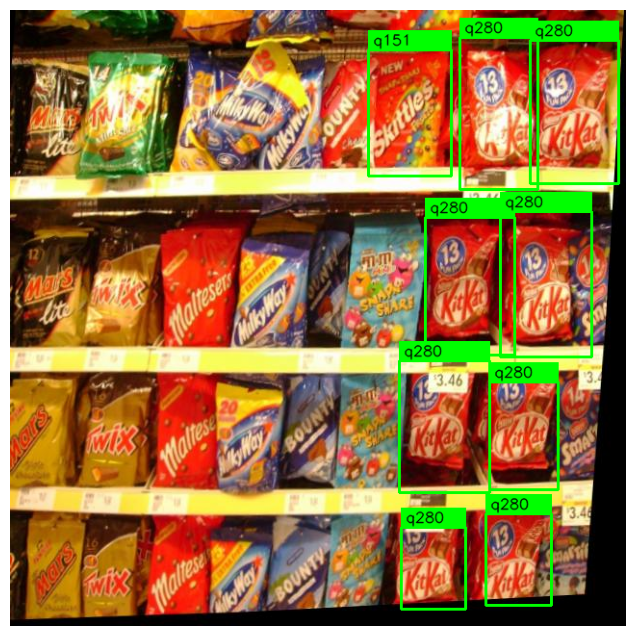

In [7]:
import cv2
import random
import matplotlib.pyplot as plt
import os


with open(yaml_path, "r") as f:
    data = yaml.safe_load(f)

class_names = data["names"]


image_files = os.listdir(image_folder)
random_image = random.choice(image_files)

img_path = os.path.join(image_folder, random_image)
label_path = os.path.join(label_folder, random_image.replace(".jpg", ".txt"))

img = cv2.imread(img_path)
h, w, _ = img.shape

# Draw bounding boxes
if os.path.exists(label_path):
    with open(label_path, "r") as f:
        for line in f.readlines():
            cls, x, y, bw, bh = map(float, line.split())

            # Convert YOLO format to pixel coordinates
            x1 = int((x - bw/2) * w)
            y1 = int((y - bh/2) * h)
            x2 = int((x + bw/2) * w)
            y2 = int((y + bh/2) * h)

            class_id = int(cls)
            label = class_names[class_id]

            cv2.rectangle(img, (x1, y1), (x2, y2), (0,255,0), 2)

            # Draw label background
            cv2.rectangle(img, (x1, y1 - 20), (x2, y1), (0,255,0), -1)

            # Put class text
            cv2.putText(
                img,
                label,
                (x1 + 5, y1 - 5),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                (0,0,0),
                1,
                cv2.LINE_AA
            )

plt.figure(figsize=(8,8))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

The images look uncorrupted, while the annotations are more or less close to the target image.

Let us check for missing data in the dataset

In [8]:
total_images = 0
total_labels = 0

for split in ['train', 'valid', 'test']:
    # img_count = len(os.listdir(f'{split}/images')) # use this line if loading data locally
    # label_count = len(os.listdir(f'{split}/labels')) # use this line if loading data locally
    img_count = len(os.listdir(f'/content/drive/MyDrive/dataset/{split}/images')) # counting images from train, val and test sets
    label_count = len(os.listdir(f'/content/drive/MyDrive/dataset/{split}/labels')) # counting labels from train, val and test sets

    print(f"{split.upper()} -> Images: {img_count}, Labels: {label_count}") # printing counts for each split

    total_images += img_count
    total_labels += label_count

print("\nTotal Images:", total_images) # printing total image count
print("Total Labels:", total_labels) # printing total label count

TRAIN -> Images: 924, Labels: 924
VALID -> Images: 40, Labels: 40
TEST -> Images: 35, Labels: 35

Total Images: 999
Total Labels: 999


There is no missing data, and the train data consists of ~92.5% of the dataset, while valid and test sets have ~4% and ~3.5% respectively.

Let us check for class imbalance

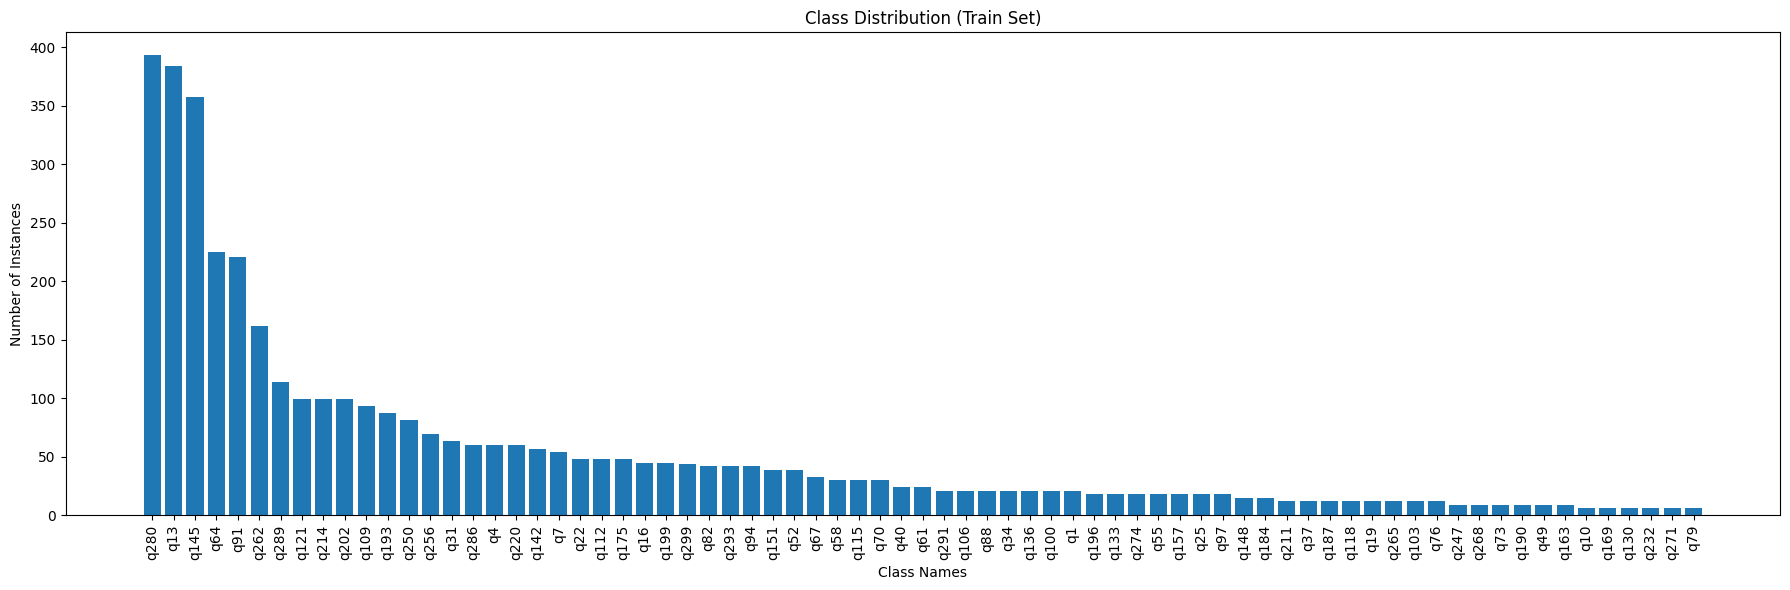

In [9]:
from collections import Counter

# Count class occurences
class_counts = Counter()

for file in os.listdir(label_folder):
    with open(os.path.join(label_folder, file), "r") as f:
        for line in f:
            cls_id = int(line.split()[0])
            class_name = class_names[cls_id]
            class_counts[class_name] += 1

# Sort for cleaner plotting
class_counts = dict(sorted(class_counts.items(), key=lambda x: x[1], reverse=True))

# Plot
plt.figure(figsize=(18,6))
plt.bar(class_counts.keys(), class_counts.values())

plt.xticks(rotation=90)
plt.xlabel("Class Names")
plt.ylabel("Number of Instances")
plt.title("Class Distribution (Train Set)")
plt.tight_layout()
plt.show()

There seems to be a noticeable class imbalance in the training dataset, which could affect generalisation capability of the trained model when subjected to new instances of classes with low occurences in the training set. We will try to see if we can produce an acceptable trained model with the data we currently have, and look towards further methods if not.

# Problem Statement

The current recall is 67.6%, meaning the model misses about 32% of the items on the shelf. In a real store, this would lead to incorrect stock counts.

**Model Optimization**: Increase the Recall metric without significantly damaging the Precision.

## Approach

We need to train a model with a resulting recall metric higher than 67.6%. Recall refers to a model's ability to detect instances of each class. A model with a high recall value would therefore detect most instances of each class (true positives) and miss as little as possible (false negatives).  

A low recall is the result of a number of reasons:

*   Small products in images being missed
*   Overlapping SKU's being suppressed
*   Low-confidence detections being discarded
*   Class imbalance

We can adopt a number of methods to try and increase recall

*   **Lower confidence threshold**: Setting the percentage at which a model is confident about the presence of an object to a low value would mean the model would miss less products during detection. This is important in a retail setting as items are usually hidden or are covered by other items in shelves.
*   **Increase Image Resolution**: Increasing image resolution would help detect small items, often the case in retail stores.
*   **Train Longer (with Early Stopping)**: Training a model longer might help when the dataset is large. However we need to keep care that the model does not overfit by implementing early stopping conditions.
*   **Handling Class Imbalance**: Using loss functions which target class imbalance could increase recall, especially in our case where some SKUs appear relatively rarely in the training images.

**Our Approach**: We will train a baseline model using default out-of-the package settings, and then train a model with higher resolution and longer epochs. While evaluating we will try out different confidence thresholds on the test data to see which threshold yields higher recall with less damaging precision.

# Model training

The dataset is a good example of a YOLO(You only look once) dataset, with text files containing annotations of the each image. In this case, a YOLO image processing model would be an obvious choice, due to its compatibility with such datasets, and its capability to process images in real time being an excellent advantage in retail environments, where keeping real-time counts of product is a necessity.

We will look towards the YOLO models from the [ultralytics library](https://docs.ultralytics.com/). The library comes with user-friendly detailed instructions for diverse use-cases.  

In [ ]:
!pip install ultralytics #installing ultralytics library

In [11]:
from ultralytics import YOLO

model_base = YOLO("yolov8m.pt")
model_base.train(
    data = yaml_path,
    epochs = 100,
    imgsz = 640,
    name = 'Baseline training',
    seed = 7
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7,

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 1,  2,  4,  5,  6,  7,  8, 10, 15, 17, 18, 19, 22, 23, 25, 32, 35, 36, 38, 40, 41, 42, 43, 47, 48, 53, 56, 58, 59, 60, 63, 65])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7a6cc0850440>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,

In [12]:
!cp -r '/content/runs/detect/Baseline training' '/content/drive/MyDrive/Retail Assessment'


In [13]:
model_high_res = YOLO("yolov8m.pt")
model_high_res.train(
    data = yaml_path,
    epochs = 150,
    imgsz = 1024,
    name = 'High_res training',
    seed = 7,
    patience = 50
)

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=High_res training, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overla

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 1,  2,  4,  5,  6,  7,  8, 10, 15, 17, 18, 19, 22, 23, 25, 32, 35, 36, 38, 40, 41, 42, 43, 47, 48, 53, 56, 58, 59, 60, 63, 65])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7a6f59f9dd60>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,

In [14]:
!cp -r '/content/runs/detect/High_res training' '/content/drive/MyDrive/Retail Assessment'


Model training with the high-resolution images stopped early at 67 epochs due to no improvements for more than 50 epochs.

# Evaluation

We will evaluate the two trained models using varying confidence thresholds. Threshold will start with 0.25 and decrease till a high value of recall is achieved without damaging the precision value significantly.

Moreover, we will be looking at the mAP50-95 (mean Average Precision across multiple IoU thresholds from 0.5 to 0.95)

In [15]:
from ultralytics import YOLO

model_base = YOLO("/content/drive/MyDrive/Retail Assessment/Baseline training/weights/best.pt")
model_high_res = YOLO("/content/drive/MyDrive/Retail Assessment/High_res training/weights/best.pt")

In [16]:
metrics_base_25 = model_base.val(
    data= yaml_path,
    split="test",
    conf=0.25,
    iou=0.6
)


Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
Model summary (fused): 93 layers, 25,883,764 parameters, 0 gradients, 78.9 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.1 ms, read: 0.4±0.1 MB/s, size: 101.1 KB)
val: Scanning /content/drive/MyDrive/dataset/test/labels.cache... 35 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 35/35 11.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 4.5s/it 13.6s
                   all         35        145      0.757      0.777      0.811      0.531
                  q106          1          3          1          1      0.995       0.68
                  q109          1          3          1          1      0.995      0.664
                  q112          2          3          1      0.333      0.667        0.6
                  q115          1          1          1          1      0.995      0.895
                  q121       

In [17]:
metrics_base_20 = model_base.val(
    data = yaml_path,
    split="test",
    conf=0.20,
    iou=0.6
)


Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
val: Fast image access ✅ (ping: 0.3±0.1 ms, read: 48.0±15.5 MB/s, size: 80.1 KB)
val: Scanning /content/drive/MyDrive/dataset/test/labels.cache... 35 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 35/35 11.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 2.6it/s 1.2s
                   all         35        145      0.744      0.805      0.822      0.543
                  q106          1          3          1          1      0.995       0.68
                  q109          1          3          1          1      0.995      0.664
                  q112          2          3          1      0.333      0.667        0.6
                  q115          1          1          1          1      0.995      0.895
                  q121          1          4      0.444          1      0.912      0.655
                   q13

In [18]:
metrics_base_15 = model_base.val(
    data = yaml_path,
    split="test",
    conf=0.15,
    iou=0.6
)


Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
val: Fast image access ✅ (ping: 0.3±0.1 ms, read: 58.6±10.9 MB/s, size: 76.5 KB)
val: Scanning /content/drive/MyDrive/dataset/test/labels.cache... 35 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 35/35 13.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 2.4it/s 1.3s
                   all         35        145      0.738      0.805      0.822      0.542
                  q106          1          3          1          1      0.995       0.68
                  q109          1          3          1          1      0.995      0.664
                  q112          2          3          1      0.333      0.667        0.6
                  q115          1          1          1          1      0.995      0.895
                  q121          1          4        0.4          1      0.912      0.654
                   q13

In [19]:
metrics_high_res_25 = model_high_res.val(
    data = yaml_path,
    split="test",
    conf=0.25,
    iou=0.6,
    imgsz = 1024
)

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
Model summary (fused): 93 layers, 25,883,764 parameters, 0 gradients, 78.9 GFLOPs
val: Fast image access ✅ (ping: 0.3±0.0 ms, read: 63.5±12.8 MB/s, size: 92.4 KB)
val: Scanning /content/drive/MyDrive/dataset/test/labels.cache... 35 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 35/35 13.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.5it/s 2.0s
                   all         35        145      0.729        0.8      0.814      0.552
                  q106          1          3       0.75          1      0.995      0.675
                  q109          1          3          1          1      0.995      0.553
                  q112          2          3          1      0.667      0.833      0.667
                  q115          1          1          1          1      0.995      0.796
                  q121       

In [20]:
metrics_high_res_20 = model_high_res.val(
    data = yaml_path,
    split="test",
    conf=0.20,
    iou=0.6,
    imgsz = 1024
)

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
val: Fast image access ✅ (ping: 0.2±0.1 ms, read: 47.4±8.0 MB/s, size: 89.4 KB)
val: Scanning /content/drive/MyDrive/dataset/test/labels.cache... 35 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 35/35 13.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.6it/s 1.9s
                   all         35        145      0.711      0.798      0.814      0.552
                  q106          1          3       0.75          1      0.995      0.675
                  q109          1          3          1          1      0.995      0.553
                  q112          2          3          1      0.667      0.833      0.667
                  q115          1          1          1          1      0.995      0.796
                  q121          1          4          1          1      0.995      0.718
                   q13 

In [21]:
metrics_high_res_15 = model_high_res.val(
    data = yaml_path,
    split="test",
    conf=0.15,
    iou=0.6,
    imgsz = 1024
)


Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
val: Fast image access ✅ (ping: 0.2±0.1 ms, read: 80.4±15.9 MB/s, size: 101.7 KB)
val: Scanning /content/drive/MyDrive/dataset/test/labels.cache... 35 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 35/35 11.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.7it/s 1.8s
                   all         35        145      0.705      0.805      0.821      0.551
                  q106          1          3       0.75          1      0.995      0.675
                  q109          1          3          1          1      0.995      0.553
                  q112          2          3          1      0.667      0.833      0.667
                  q115          1          1          1          1      0.995      0.796
                  q121          1          4      0.837          1      0.995      0.716
                   q1

In [22]:
def print_metrics(name, metrics):
    print(f"{name:<18} "
          f"{metrics.results_dict['metrics/recall(B)']:.4f}      "
          f"{metrics.results_dict['metrics/precision(B)']:.4f}      "
          f"{metrics.box.map50:.4f}      "
          f"{metrics.box.map:.4f}")

print("\n================ MODEL COMPARISON ================")
print("Model/Conf         Recall     Precision   mAP@0.5    mAP@0.5:0.95")
print("---------------------------------------------------------------")

# Base Model
print_metrics("Base (0.25)", metrics_base_25)
print_metrics("Base (0.20)", metrics_base_20)
print_metrics("Base (0.15)", metrics_base_15)

print("---------------------------------------------------------------")

# High-Res Model
print_metrics("HighRes (0.25)", metrics_high_res_25)
print_metrics("HighRes (0.20)", metrics_high_res_20)
print_metrics("HighRes (0.15)", metrics_high_res_15)

print("===============================================================")


================ MODEL COMPARISON ================
Model/Conf         Recall     Precision   mAP@0.5    mAP@0.5:0.95
---------------------------------------------------------------
Base (0.25)        0.7774      0.7570      0.8108      0.5311
Base (0.20)        0.8047      0.7441      0.8222      0.5427
Base (0.15)        0.8047      0.7379      0.8216      0.5423
---------------------------------------------------------------
HighRes (0.25)     0.8001      0.7288      0.8144      0.5522
HighRes (0.20)     0.7985      0.7113      0.8137      0.5517
HighRes (0.15)     0.8046      0.7047      0.8213      0.5509


### Results Discussion

All the models achieve a recall value more than 67.6, with recall mostly increasing with decrease in confidence thresholds. The high-res model achieves high recall values but also produces lower precision at iou 0.6 when compared to base model. However, mean average precision is higher for HighRes models, indicating better generalisation capability of the models.

### Verdict

From the results, the base model with confidence threshold 0.15 and high-res model with confidence threshold of 0.25 are suitable models for the retail stock detection, due to high recall and acceptable precision values. Due to the assignment clearly indicating a high recall and focuses on less precision damaging model, **Base model with 0.15 conf** would be the final chosen model.

In [24]:
final_model = YOLO("/content/drive/MyDrive/Retail Assessment/Baseline training/weights/best.pt")

# Share of Shelf Analytics:

## Problem Statement
Treat the entire test dataset as a single representative shelf of a store. Calculate and visualize the "Percentage Share of Shelf" for each of the product classes (SKUs).

### Approach
In the next steps, We will map the numerical class IDs (SKU IDs) to their corresponding human-readable class names using the 'names' field from the loaded data.yaml. Then, we will calculate the percentage share for each class by dividing its count by the total number of detected items. Finally, we will visualize the 'Percentage Share of Shelf' for each product class using a bar chart and summarize the analysis, highlighting any dominant product classes.

In [25]:
from ultralytics import YOLO
from collections import Counter
import os

# Construct the correct path to the test images
test_image_path = os.path.join(data["path"], data["test"])

# model = YOLO("/content/drive/MyDrive/Retail Assessment/Baseline training2/weights/best.pt")
results = final_model(test_image_path)

all_labels = []

for r in results:
    labels = r.boxes.cls.cpu().numpy()
    all_labels.extend(labels)

counts = Counter(all_labels)
total = sum(counts.values())

share_of_shelf_data = {}
class_names = data["names"]

for class_id, count in counts.items():
    class_name = class_names[int(class_id)]
    percentage = (count / total) * 100
    share_of_shelf_data[class_name] = percentage



image 1/35 /content/drive/MyDrive/dataset/test/images/db1050_jpg.rf.6c337978ee69a3a3a31ce3063e861053.jpg: 640x640 (no detections), 10.1ms
image 2/35 /content/drive/MyDrive/dataset/test/images/db1127_jpg.rf.61a0266165bd6c8bec8f851b88a941c7.jpg: 640x640 9 q121s, 9.9ms
image 3/35 /content/drive/MyDrive/dataset/test/images/db1170_jpg.rf.c7c3dd2d1600ab4f4ae08b22acf44b7f.jpg: 640x640 3 q106s, 9.7ms
image 4/35 /content/drive/MyDrive/dataset/test/images/db1205_jpg.rf.c02173b52c990ff307ad8896a541f7b6.jpg: 640x640 3 q109s, 9.2ms
image 5/35 /content/drive/MyDrive/dataset/test/images/db1210_jpg.rf.78c93d96b882930f89575010a4b3be97.jpg: 640x640 3 q286s, 9.2ms
image 6/35 /content/drive/MyDrive/dataset/test/images/db1212_jpg.rf.6c1c5f6b8918d257a07545f7ec4c0840.jpg: 640x640 2 q286s, 9.1ms
image 7/35 /content/drive/MyDrive/dataset/test/images/db1268_jpg.rf.90d1222a97077ebbd703047fff8d42c7.jpg: 640x640 24 q214s, 9.3ms
image 8/35 /content/drive/MyDrive/dataset/test/images/db1307_jpg.rf.5aef1e6ad32d866860

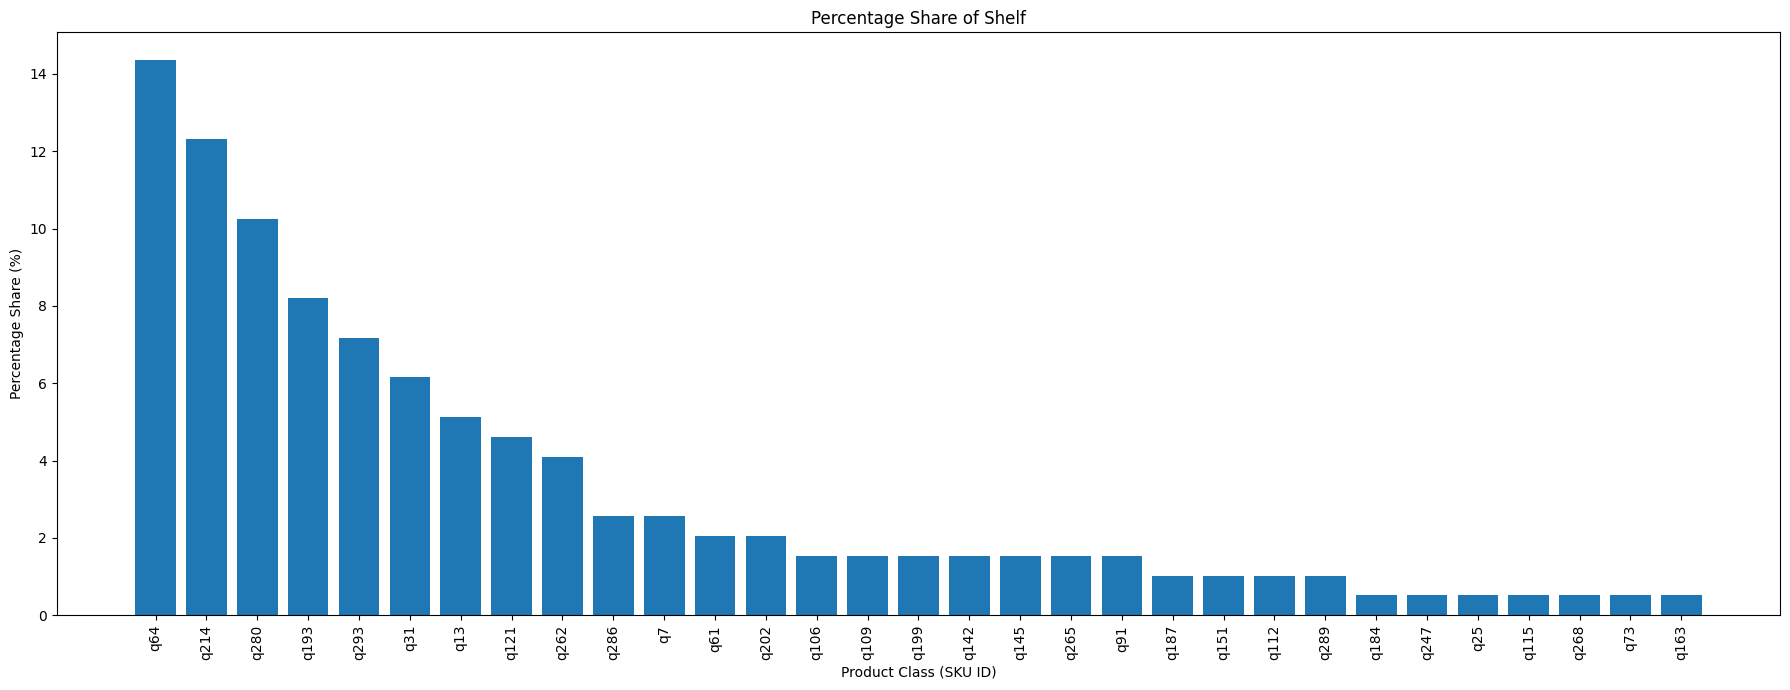

In [26]:
# Sort by percentage (descending)
sorted_items = sorted(share_of_shelf_data.items(), key=lambda x: x[1], reverse=True)

class_labels = [item[0] for item in sorted_items]
percentages = [item[1] for item in sorted_items]

plt.figure(figsize=(18, 7))
plt.bar(class_labels, percentages)

plt.title('Percentage Share of Shelf')
plt.xlabel('Product Class (SKU ID)')
plt.ylabel('Percentage Share (%)')
plt.xticks(rotation=90)
plt.tight_layout()

plt.savefig("share_of_shelf.png", dpi=300, bbox_inches='tight')

plt.show()

### Summary of Share of Shelf Analysis

The bar chart above illustrates the 'Percentage Share of Shelf' for each product class (SKU ID) in the test dataset. By examining the chart, we can identify product classes that are dominant on the shelf. These insights are crucial for inventory management, promotional strategies, and understanding product placement effectiveness in a retail environment.

From the visualization, it is clear that **q64** and **q214** are the most dominant product classes, occupying the largest percentages of the shelf. Several other classes like **q280**, **q193**, and **q293** also hold significant shares. Conversely, many classes like **q184**, **q247**, **q25**, **q115**, **q268**, **q73**, and **q163** have a very small percentage, indicating they are less dominant or present in lower quantities. This information can help retailers make informed decisions about stocking levels and merchandising.